In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

notebook_dir = Path.cwd()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from compare_laces_policies import collect_rows, aggregate_rows, plot_metric_grid, plot_utilization_grid, DEFAULT_METRICS

In [3]:
# Update these paths if your logs are elsewhere.
notebook_dir = Path.cwd()

project_root = None
for candidate in [notebook_dir, *notebook_dir.parents]:
    if (candidate / 'scripts' / 'laces').exists() and (candidate / 'scripts' / 'laces_mab').exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError('Cannot locate project root that contains scripts/laces and scripts/laces_mab.')

inputs = [
    # str(project_root / 'scripts' / 'laces' / 'output' / '13-04-2026_11-38' / 'default_config' / 'ite1.log'),
    # str(project_root / 'scripts' / 'laces_mab' / 'output' / '13-04-2026_12-26' / 'default_config' / 'ite1.log'),
    str(project_root / 'scripts' / 'laces' / 'output' / '13-04-2026_13-52' / 'default_config' / 'ite1.log'),
    str(project_root / 'scripts' / 'laces_mab' / 'output' / '13-04-2026_13-26' / 'default_config' / 'ite1.log'),
    str(project_root / 'scripts' / 'laces_will' / 'output' / '18-04-2026_15-37' / 'default_config' / 'ite1.log'),
]

output_dir = (notebook_dir / 'comparison_plots').resolve()
output_dir.mkdir(parents=True, exist_ok=True)
prefix = 'laces_vs_laces_mab'

raw_df = collect_rows(inputs)
summary_df = aggregate_rows(raw_df)
summary_df

,policy,device_count,failed_percentage,throughput,service_time,processing_time,network_delay,edge_utilization,cloud_utilization,overhead_ns,completed_tasks,failed_tasks,total_tasks
0,LACES,200,0.286012,30.713095,0.641146,0.489458,0.151688,0.692354,0.279530,2715.002667,25799.0,74.0,25873.0
1,LACES,400,0.305159,61.839286,0.729882,0.575858,0.154024,1.742809,0.593289,2633.097421,51945.0,159.0,52104.0
2,LACES,600,0.396224,86.786905,0.788391,0.626239,0.162152,2.727469,0.761074,3001.930688,72901.0,290.0,73191.0
3,LACES,800,0.417964,117.992857,0.873676,0.705509,0.168167,4.320110,1.087919,3839.183734,99114.0,416.0,99530.0
4,LACES,1000,0.406290,141.533333,0.900118,0.727370,0.172749,5.415388,1.311745,4511.486199,118888.0,485.0,119373.0
5,LACES,1200,0.447042,176.033333,1.021126,0.838079,0.183047,7.808365,1.474832,5986.576192,147868.0,664.0,148532.0
6,LACES,1400,0.537767,211.816667,1.131124,0.937779,0.193345,10.556927,1.964430,8974.605602,177926.0,962.0,178888.0
7,LACES,1600,0.567096,241.505952,1.219829,1.014856,0.204972,13.106663,2.227517,13678.627035,202865.0,1157.0,204022.0
8,LACES,1800,0.878157,270.496429,1.416772,1.152724,0.264048,16.552972,3.702685,18605.319360,227217.0,2013.0,229230.0
9,LACES_MAB,200,0.338732,30.472619,0.646456,0.438186,0.208270,0.612176,0.341275,3563.694596,25597.0,87.0,25684.0


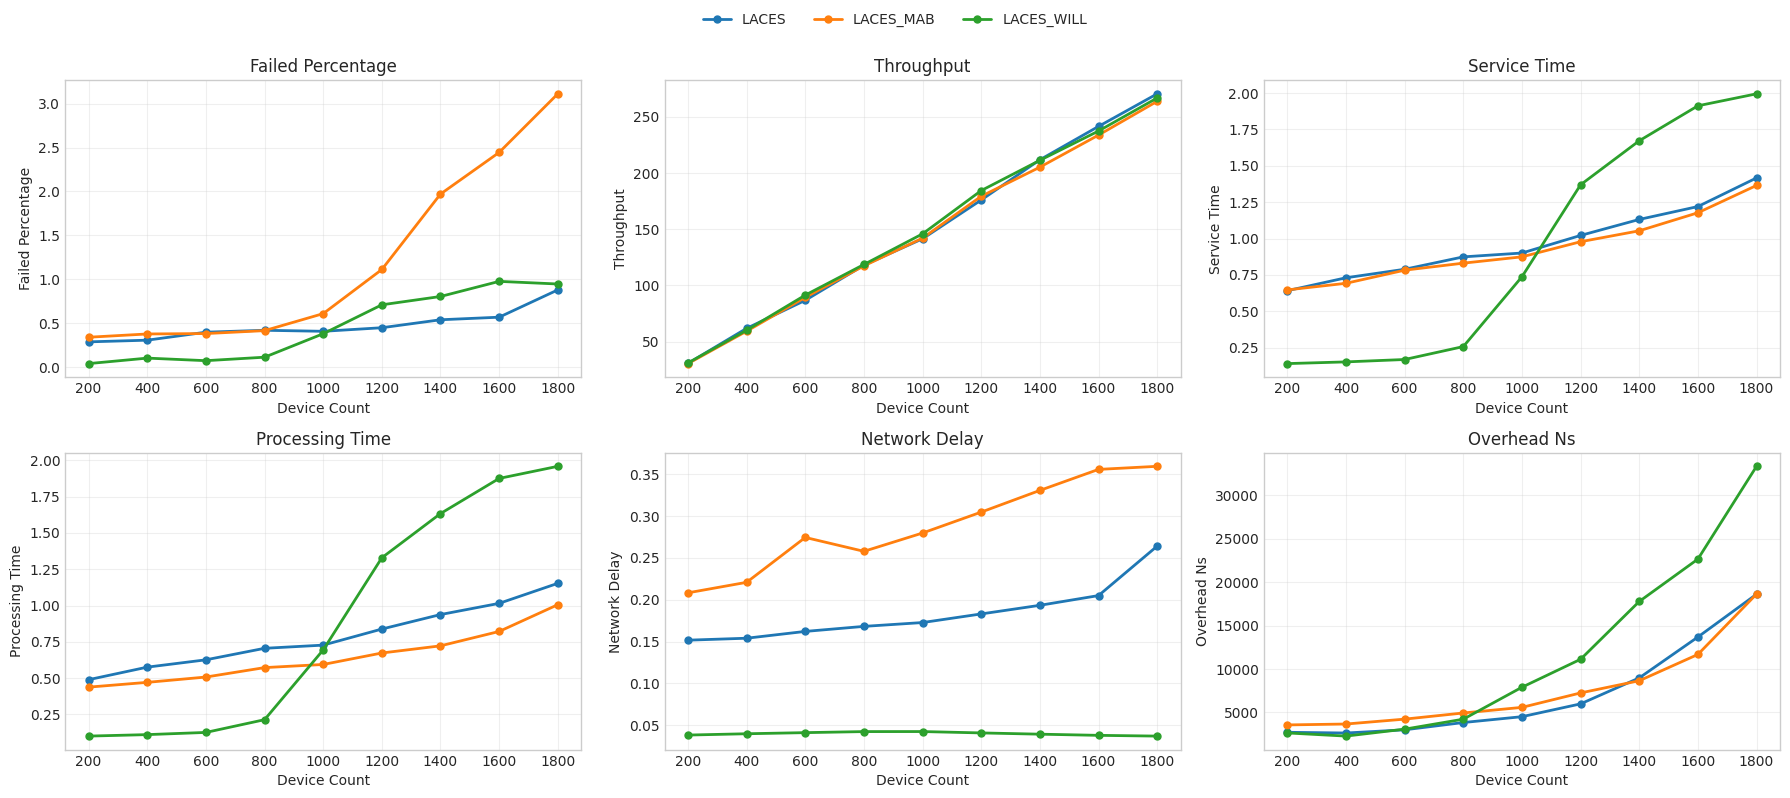

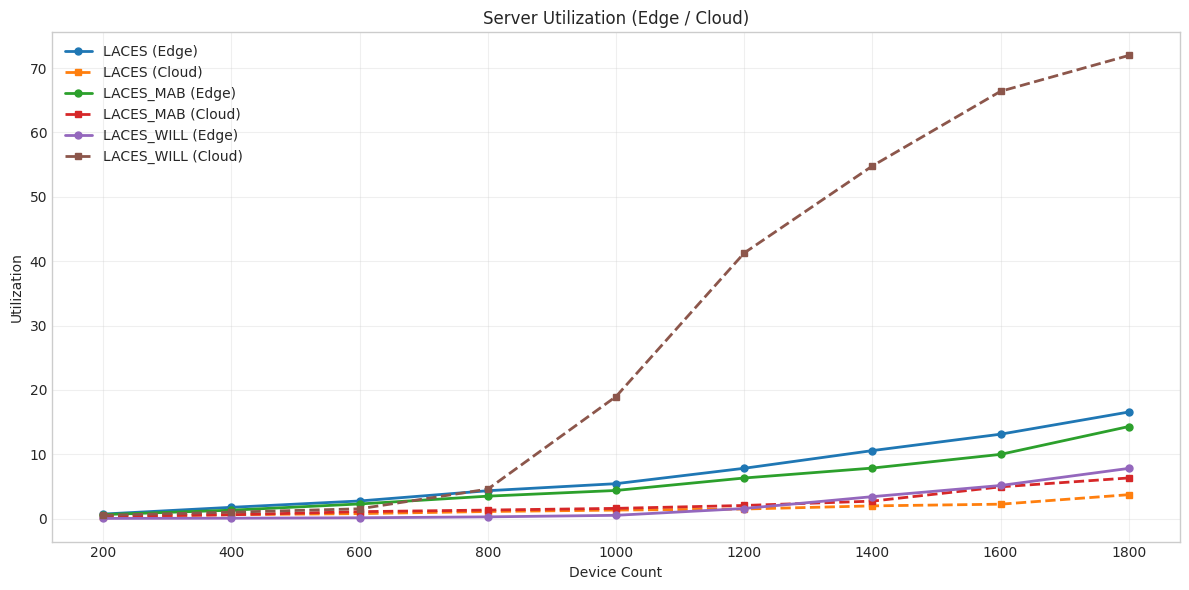

Saved summary CSV: /workspace/EdgeCloudSim/scripts/laces_mab/python/comparison_plots/laces_vs_laces_mab_summary.csv
Saved metrics plot: /workspace/EdgeCloudSim/scripts/laces_mab/python/comparison_plots/laces_vs_laces_mab_core_metrics.png
Saved utilization plot: /workspace/EdgeCloudSim/scripts/laces_mab/python/comparison_plots/laces_vs_laces_mab_utilization.png


In [4]:
csv_path = output_dir / f'{prefix}_summary.csv'
summary_df.to_csv(csv_path, index=False)

metrics_plot_path = output_dir / f'{prefix}_core_metrics.png'
util_plot_path = output_dir / f'{prefix}_utilization.png'

plot_metric_grid(summary_df, metrics_plot_path, DEFAULT_METRICS)
plot_utilization_grid(summary_df, util_plot_path)

print(f'Saved summary CSV: {csv_path}')
print(f'Saved metrics plot: {metrics_plot_path}')
print(f'Saved utilization plot: {util_plot_path}')